In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Phase 1: Verification
Verification if all files are imported successfully.

In [23]:
import pandas as pd

In [24]:
df = pd.read_csv("tokopedia_product_reviews_2025.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   review_text       65543 non-null  str  
 1   review_date       65543 non-null  str  
 2   review_id         65543 non-null  int64
 3   product_name      65543 non-null  str  
 4   product_category  65543 non-null  str  
 5   product_variant   26749 non-null  str  
 6   product_price     65543 non-null  int64
 7   product_url       65543 non-null  str  
 8   product_id        65543 non-null  int64
 9   rating            65543 non-null  int64
 10  sold_count        65543 non-null  int64
 11  shop_id           65543 non-null  int64
 12  sentiment_label   65543 non-null  str  
dtypes: int64(6), str(7)
memory usage: 6.5 MB


65543 rows and 13 columns, column names seems correct as well. product_variant has missing values, but doesn't matter for now.

In [25]:
df.head(5)

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


## Phase 2: Cleaning

In [26]:
import importlib
import pipeline

importlib.reload(pipeline)

<module 'pipeline' from 'c:\\Users\\User\\Documents\\Projects\\E-Commerce_NLP\\pipeline.py'>

Let's test a few texts.

In [27]:
test_list = [i for i in df.loc[100:109, "review_text"]]
for i in test_list:
    print(i)

paket sampai sesuai waktu, packing rapi, kemasan bagus ,real pict, sesuai jumlah, kualitas mantap, rasa enak, bumbunya pas, expired date masih lama, favorit keluarga, rekomendasi jadi langganan. Terima kasih.
mie original . packing rapi. aman meskipun cuma di kasih plastik packing karena pakai GTL. expire masih 7 bulan lagi . sampai 27 Mei 2025. fast response. recommended seller. sore pesan. besok siang sudah sampai
produk ori.mie sedaap favorite keluarga kita 👍🏻.packing rapi. expire aman. masih 8 bulan lagi.sampai 30 April 2025. fast response. recommended seller
sesuai pesanan klop tidak ada kekurangan, plus bonus nya juga bagus bermanfaat, sampai secepat kilat by Sameday , packing as always selalu aman with box and bubble, thanks ,, **foto tidak sesuai pesanan krn lupa take photos orderan yg ini
packing rapih, sampai tepat waktu, barang sesuai deskripsi, seller ramah
paket terkirim cepat, isi aman dan lengkap. packing aman dg bubble wrap tebal
Paketnya sudah sampai, semua sesuai pesa

In [28]:
test_list_clean = [pipeline.clean_review_text(i) for i in df.loc[100:109, "review_text"]]
for i in test_list_clean:
    print(i)

paket sampai sesuai waktu packing rapi kemasan bagus real pict sesuai jumlah kualitas mantap rasa enak bumbunya pas expired date masih lama favorit keluarga rekomendasi jadi langganan terima kasih
mie original packing rapi aman meskipun cuma di kasih plastik packing karena pakai gtl expire masih 7 bulan lagi sampai 27 mei 2025 fast response recommended seller sore pesan besok siang sudah sampai
produk orimie sedaap favorite keluarga kita jempol ke atas warna kulit cerah packing rapi expire aman masih 8 bulan lagisampai 30 april 2025 fast response recommended seller
sesuai pesanan klop tidak ada kekurangan plus bonus nya juga bagus bermanfaat sampai secepat kilat by sameday packing as always selalu aman with box and bubble thanks foto tidak sesuai pesanan krn lupa take photos orderan yg ini
packing rapih sampai tepat waktu barang sesuai deskripsi seller ramah
paket terkirim cepat isi aman dan lengkap packing aman dg bubble wrap tebal
paketnya sudah sampai semua sesuai pesanan packing ra

#### Observation: Looking at most popular words
We will use other strategy, but this observation is to demonstrate a strategy which involves converting the most common slangs/abbreviated words that appear in all our reviews available.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# creating a new dataframe that only contains all cleaned review text
df_cleanreviews = df["review_text"].apply(pipeline.clean_review_text)
df_cleanreviews

0        baru sekali ini terima brg dr belanja online d...
1        cocok bgt aku sama telur nya nga amis menurutk...
2        telornya sudah sampai di rumah dengan kemasan ...
3        telor sudah diterima dengan baik dan tidak ada...
4        alhamdulillah penjual amanahtelor nya terbaiks...
                               ...                        
65538               kwalitas bagus pokoknya rekomendit deh
65539                                         sesuai harga
65540                                         sesuai harga
65541                                               mantap
65542                                diterima sesuai order
Name: review_text, Length: 65543, dtype: str

In [31]:
# splitting them and then exploding them for future value_counts()
df_cr_exp = df_cleanreviews.str.split().explode()

# now filtering them to those with less than 3 words (since slangs are usually that short)
df_cr_exp_fil = df_cr_exp[df_cr_exp.str.len() <= 3]

In [32]:
# now count each word appearance and reset their index
df_cr_exp_fil_vc = df_cr_exp_fil.value_counts().reset_index()
df_cr_exp_fil_vc

,review_text,count
0,dan,23175
1,ke,12362
2,di,8458
3,nya,6941
4,yg,5371
...,...,...
2242,txh,1
2243,pto,1
2244,wtt,1
2245,kll,1


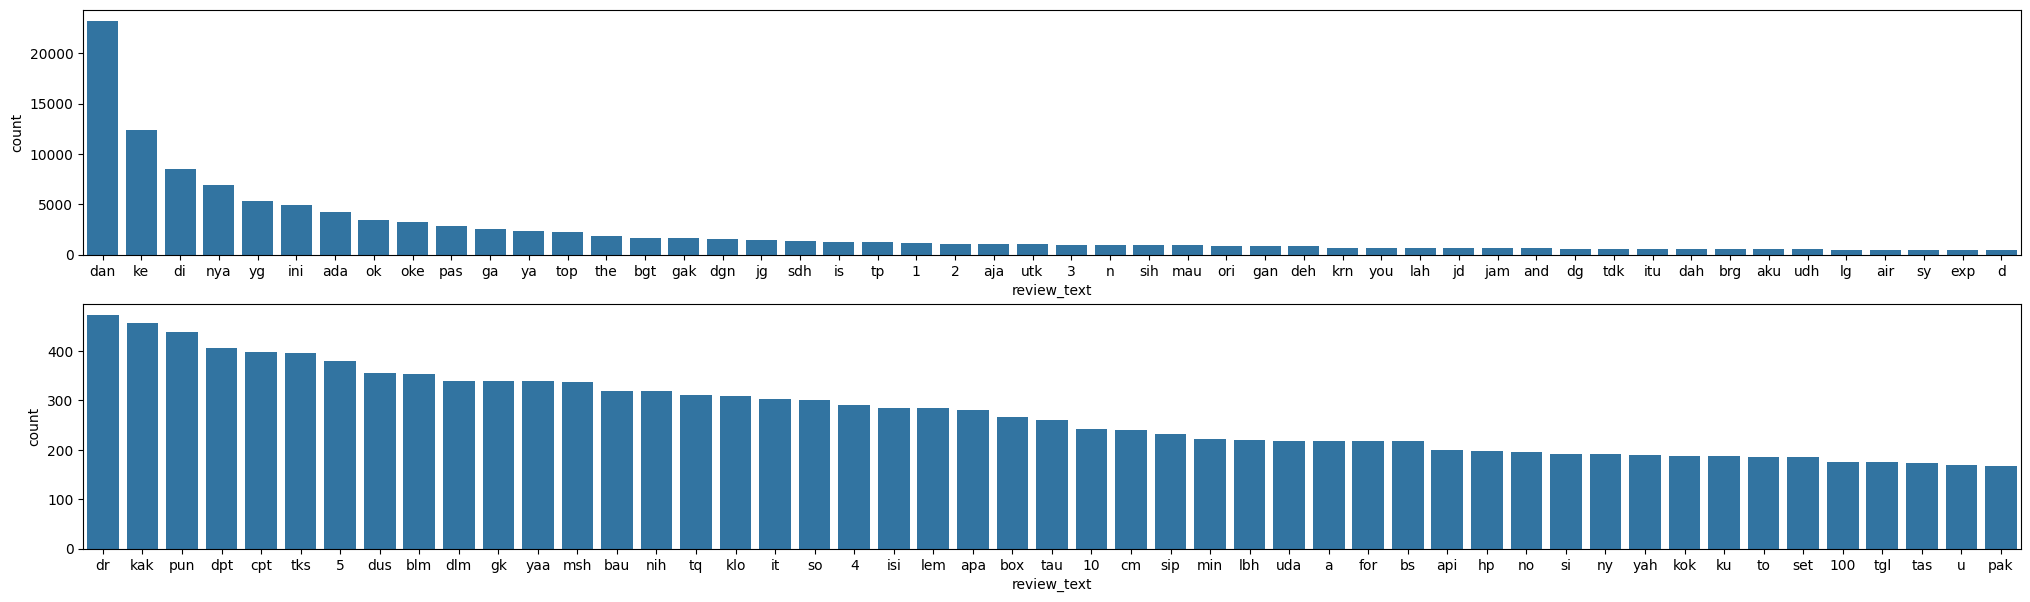

In [33]:
# visualizing top the top 100 in 2 different subplots
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(25,7))
sns.barplot(data=df_cr_exp_fil_vc.head(50), x="review_text", y="count", ax=ax[0])
sns.barplot(data=df_cr_exp_fil_vc[51:100], x="review_text", y="count", ax=ax[1])
plt.show()

Note: We can try making a slang map out of the most common slang words that appeared here, however we will try to use an open-source dictionary instead (for more accurate industry experience and to save time)

In [34]:
data = pd.read_csv("colloquial-indonesian-lexicon.csv")
data

,slang,formal,In-dictionary,context,category1,category2,category3
0,woww,wow,1,wow,elongasi,0,0
1,aminn,amin,1,Selamat ulang tahun kakak tulus semoga panjang...,elongasi,0,0
2,met,selamat,1,Met hari netaas kak!? Wish you all the best @t...,abreviasi,0,0
3,netaas,menetas,1,Met hari netaas kak!? Wish you all the best @t...,afiksasi,elongasi,0
4,keberpa,keberapa,0,Birthday yg keberpa kak?,abreviasi,0,0
...,...,...,...,...,...,...,...
15001,gataunya,enggak taunya,0,Ini kaya nenek2 ya beb gataunya agnezz @yugime...,akronim,0,0
15002,gtau,enggak tau,0,Stidaknya mrka may berkarya Dan berusaha yg tr...,akronim,abreviasi,0
15003,gatau,enggak tau,0,Ih gatau malu,akronim,0,0
15004,fans2,fan-fan,0,Jkt48 adalah tempat di mana sesama fans saling...,reduplikasi,naturalisasi,0


In [35]:
raw_reviews = [pipeline.clean_review_text(i) for i in df.loc[100:109, "review_text"]]
data = data.loc[:, ["slang", "formal"]]
data

,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa
...,...,...
15001,gataunya,enggak taunya
15002,gtau,enggak tau
15003,gatau,enggak tau
15004,fans2,fan-fan


In [36]:
raw_reviews

['paket sampai sesuai waktu packing rapi kemasan bagus real pict sesuai jumlah kualitas mantap rasa enak bumbunya pas expired date masih lama favorit keluarga rekomendasi jadi langganan terima kasih',
 'mie original packing rapi aman meskipun cuma di kasih plastik packing karena pakai gtl expire masih 7 bulan lagi sampai 27 mei 2025 fast response recommended seller sore pesan besok siang sudah sampai',
 'produk orimie sedaap favorite keluarga kita jempol ke atas warna kulit cerah packing rapi expire aman masih 8 bulan lagisampai 30 april 2025 fast response recommended seller',
 'sesuai pesanan klop tidak ada kekurangan plus bonus nya juga bagus bermanfaat sampai secepat kilat by sameday packing as always selalu aman with box and bubble thanks foto tidak sesuai pesanan krn lupa take photos orderan yg ini',
 'packing rapih sampai tepat waktu barang sesuai deskripsi seller ramah',
 'paket terkirim cepat isi aman dan lengkap packing aman dg bubble wrap tebal',
 'paketnya sudah sampai semua

In [37]:
sample = raw_reviews[7]
sample

'bagus smua gak ada y penyoksmua lengkap sesuai pesanan wajah dengan tangan menutup mulut wajah konyol'

In [38]:
sample = sample.split()
sample

['bagus',
 'smua',
 'gak',
 'ada',
 'y',
 'penyoksmua',
 'lengkap',
 'sesuai',
 'pesanan',
 'wajah',
 'dengan',
 'tangan',
 'menutup',
 'mulut',
 'wajah',
 'konyol']

In [39]:
slang_dict = dict(zip(data["slang"], data["formal"]))
slang_dict

{'woww': 'wow',
 'aminn': 'amin',
 'met': 'selamat',
 'netaas': 'menetas',
 'keberpa': 'keberapa',
 'eeeehhhh': 'eh',
 'kata2nyaaa': 'kata-katanya',
 'hallo': 'halo',
 'kaka': 'kakak',
 'ka': 'kak',
 'daah': 'dah',
 'aaaaahhhh': 'ah',
 'yaa': 'ya',
 'smga': 'semoga',
 'slalu': 'selalu',
 'amiin': 'amin',
 'kk': 'kakak',
 'trus': 'terus',
 'sii': 'sih',
 'nyenengin': 'menyenangkan',
 'bgt': 'banget',
 'gemess': 'gemas',
 'akuuu': 'aku',
 'jgn': 'jangan',
 'udah': 'sudah',
 'gitu': 'begitu',
 'aja': 'saja',
 'gemesiin': 'menggemaskan',
 'menyenangkn': 'menyenangkan',
 'rb': 'ribu',
 'akau': 'aku',
 'saranin': 'menyarankan',
 'nemuin': 'menemukan',
 'yah': 'ya',
 'mnis2nya': 'manis-manisnya',
 'gtu': 'begitu',
 'tu': 'itu',
 'idolaa': 'idola',
 'bangett': 'banget',
 'kaakk': 'kak',
 'baaiikkk': 'baik',
 'telaatt': 'telat',
 'kaak': 'kak',
 'yg': 'yang',
 'lg': 'lagi',
 'skarang': 'sekarang',
 'sempet': 'sempat',
 'karna': 'karena',
 'ngga': 'enggak',
 'mantep': 'mantap',
 'loohhh': 'loh',

In [40]:
sample = [slang_dict.get(i, i) for i in sample]
sample

['bagus',
 'semua',
 'enggak',
 'ada',
 'ya',
 'penyoksmua',
 'lengkap',
 'sesuai',
 'pesanan',
 'wajah',
 'dengan',
 'tangan',
 'menutup',
 'mulut',
 'wajah',
 'konyol']

In [41]:
new_sample = " ".join(sample)
new_sample

'bagus semua enggak ada ya penyoksmua lengkap sesuai pesanan wajah dengan tangan menutup mulut wajah konyol'

We have integrated above procedures of replacing most slangs/abbreviation with their formal terms in our pipeline file. Observe the result below.

In [42]:
slang_path = "colloquial-indonesian-lexicon.csv"
slang_dict = pipeline.initialize_dict(slang_path)
test_list_cleaner = [pipeline.clean_review_text(i, slang_dict) for i in df.loc[100:109, "review_text"]]
test_list_cleaner

['paket sampai sesuai waktu packing rapi kemasan bagus real pict sesuai jumlah kualitas mantap rasa enak bumbunya pas expired date masih lama favorit keluarga rekomendasi jadi langganan terima kasih',
 'mie original packing rapi aman meskipun cuma di kasih plastik packing karena pakai gtl expire masih 7 bulan lagi sampai 27 mei 2025 fast response recommended seller sore pesan besok siang sudah sampai',
 'produk orimie sedaap favorite keluarga kita jempol ke atas warna kulit cerah packing rapi expire aman masih 8 bulan lagisampai 30 april 2025 fast response recommended seller',
 'sesuai pesanan klop tidak ada kekurangan plus bonus nya juga bagus bermanfaat sampai secepat kilat by sameday packing as always selalu aman with box and bubble thanks foto tidak sesuai pesanan karena lupa take photos orderan yang ini',
 'packing rapi sampai tepat waktu barang sesuai deskripsi seller ramah',
 'paket terkirim cepat isi aman dan lengkap packing aman dengan bubble wrap tebal',
 'paketnya sudah samp

Great, now let's apply this to our actual data.

In [44]:
df["review_text_cleaned"] = df["review_text"].apply(lambda x : pipeline.clean_review_text(x, data_dict=slang_dict))

In [53]:
print(df[["review_text", "review_text_cleaned"]].sample(5))

                                             review_text  \
54940           Size &amp; jml sesuai semua terima kasih   
5697              👍👍👍👍👍👍👍 cepat dan terjamin kualitasnya   
12000        kualitas barang, kemasan &amp; wkt kirim ok   
55501  barang berfungsi dengan baik, tas nya besar da...   
34751                                               joss   

                                     review_text_cleaned  
54940                 size jml sesuai semua terima kasih  
5697   jempol ke atas jempol ke atas jempol ke atas j...  
12000             kualitas barang kemasan waktu kirim ok  
55501  barang berfungsi dengan baik tas nya besar dan...  
34751                                               joss  
